# XGBoost

## Imports

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import FunctionTransformer

from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX
from heart_failure.config.train import (
    TEST_SIZE, RANDOM_STATE, VAL_SIZE, FS_VALID_SIZE
)
from heart_failure.config.modeling import (
    CV_SPLITS, OPTUNA_N_TRIALS, F_BETA_THRESHOLD, MIN_RECALL, MODEL_STEP_NAME, COL_SEL_STEP_NAME
)

from heart_failure.feature_selection import shap_fs
from heart_failure.features import get_fe_pipeline
from heart_failure.dataset import split_data

from heart_failure.modeling.models import build_xgboost_pipeline
from heart_failure.modeling.train import optuna_search, xgboost_space
from heart_failure.modeling.cv import cross_val_score_sw
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold
)

from heart_failure.plots import plot_pr_curve
from heart_failure.reports import print_best_params

In [2]:
MODEL_NAME = "xgboost"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

### First iteration

In [ ]:
fe_pipeline = get_fe_pipeline(conj_feature=False)
cv_params = {"sample_weight": X_train[SEX].map({"F": 1, "M": 1})}
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_xgboost_pipeline,
    param_space=xgboost_space,
    n_trials=30,
    n_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
    n_jobs=8,
    cv_params=cv_params,
    cv_scorer=cross_val_score_sw
)

In [5]:
print_best_params(study)

Best parameters: {'model__n_estimators': 623, 'model__learning_rate': 0.07562383764615785, 'model__gamma': 1.9122167157791334, 'model__max_depth': 2, 'model__reg_lambda': 0.23481086869597192, 'model__reg_alpha': 0.05177533076836435, 'model__subsample': 0.9596128956537178, 'feature_engineering__preprocessor__use_binner': True, 'column_selector__top_k': 12}
Best score: 0.80775


#### SHAP values

In [6]:
feature_stats = shap_fs(X_train, y_train, model, test_size=FS_VALID_SIZE)
feature_stats

,feature,shap_mean,shap_std
0,ST_Slope_Sex_te,0.614141,0.199690
1,ChestPainType_RestingECG_te,0.539174,0.100966
2,Oldpeak_Cholesterol_ST_Slope_te,0.484818,0.238973
3,ST_Slope_RestingECG_te,0.349450,0.176593
4,ChestPainType_Sex_te,0.286033,0.084857
5,FastingBS,0.270205,0.190819
6,ST_Slope,0.231512,0.053577
7,Oldpeak,0.213350,0.340516
8,Age_MaxHR_ratio,0.178489,0.220499
9,ExerciseAngina,0.172913,0.073126


### Second iteration

In [ ]:
fe_pipeline = get_fe_pipeline(conj_feature=False)
cs_params = {"remaining_columns": None, "top_list": feature_stats["feature"].to_list()}
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_xgboost_pipeline,
    param_space=xgboost_space,
    n_trials=100,
    n_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
    n_jobs=8,
    cv_params=cv_params,
    cv_scorer=cross_val_score_sw,
    cs_params=cs_params,
)

In [8]:
print_best_params(study)

Best parameters: {'model__n_estimators': 754, 'model__learning_rate': 0.022553613500082125, 'model__gamma': 1.665615643868475, 'model__max_depth': 2, 'model__reg_lambda': 1.8217834566775704, 'model__reg_alpha': 0.5958377616571663, 'model__subsample': 0.7631440996633397, 'feature_engineering__preprocessor__use_binner': True, 'column_selector__top_k': 14}
Best score: 0.83257


In [9]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
82,"{'model__n_estimators': 754, 'model__learning_...",0.047426,0.832568,0.800000,0.839506,0.850000,0.906667,0.766667,1
84,"{'model__n_estimators': 754, 'model__learning_...",0.046720,0.828813,0.800000,0.841463,0.829268,0.906667,0.766667,2
81,"{'model__n_estimators': 473, 'model__learning_...",0.049067,0.824819,0.781609,0.839506,0.850000,0.894737,0.758242,3
80,"{'model__n_estimators': 475, 'model__learning_...",0.039053,0.823712,0.800000,0.839506,0.829268,0.883117,0.766667,4
48,"{'model__n_estimators': 610, 'model__learning_...",0.049480,0.823137,0.781609,0.841463,0.819277,0.906667,0.766667,5


#### Feature importance

In [10]:
top_k = model.named_steps[COL_SEL_STEP_NAME].top_k
rem_cols = feature_stats[: top_k]["feature"]
index = fe_pipeline.transform(X)[rem_cols].columns
tree = model.named_steps[MODEL_STEP_NAME]
pd.Series(tree.feature_importances_, index=index).sort_values(ascending=False)

ST_Slope_Sex_te                    0.347634
Oldpeak_Cholesterol_ST_Slope_te    0.143010
ChestPainType_RestingECG_te        0.068349
ExerciseAngina                     0.066060
Oldpeak_ChestPainType_te           0.057692
ChestPainType_Sex_te               0.050795
ST_Slope                           0.042728
FastingBS                          0.039081
ST_Slope_RestingECG_te             0.037100
MaxHR                              0.034206
Age_Cholesterol_Sex_te             0.031117
ExerciseAngina_RestingECG_te       0.029585
Age_MaxHR_ratio                    0.026891
Oldpeak                            0.025752
dtype: float32

### Threshold searching

In [11]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

np.float32(0.291711)

## Metrics

In [12]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.897019
recall       0.929775
fpr          0.131488
pr_auc       0.965709
dtype: float64

In [13]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.786885
recall       0.979592
fpr          0.333333
pr_auc       0.950371
dtype: float64

The model is better than all previous ones, but the FPR is still too high. I'd like to see it reduced to at least 0.25.

### Confusion Matrix

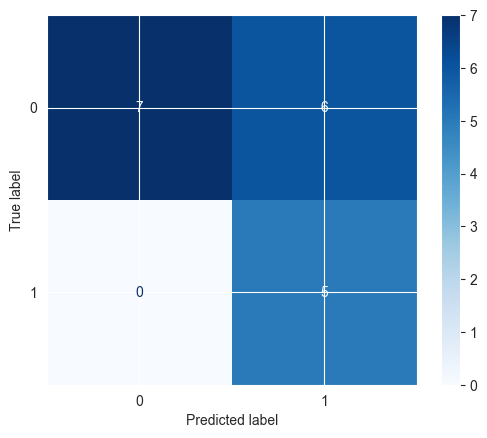

In [14]:
female = X_val[SEX] == "F"
ConfusionMatrixDisplay.from_predictions(y_val[female], y_val_pred[female], cmap="Blues")
plt.show()

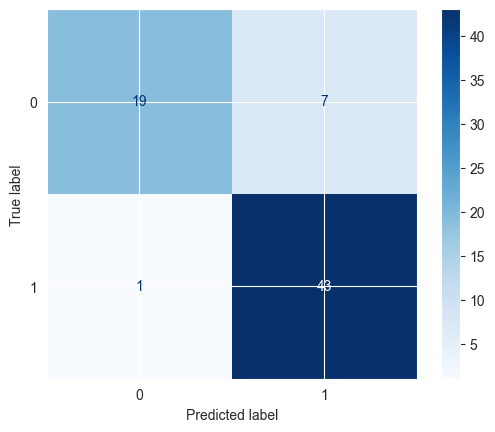

In [15]:
ConfusionMatrixDisplay.from_predictions(y_val[~female], y_val_pred[~female], cmap="Blues")
plt.show()

When using sample_weight, FP for women does not change at all - it is always 6.

### PR-curve

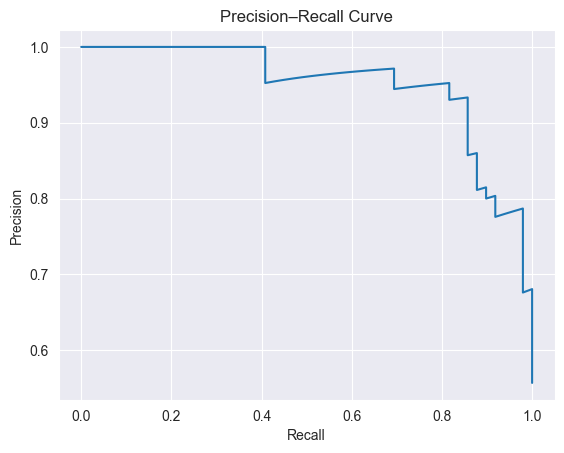

In [16]:
plot_pr_curve(y_val, y_val_proba)

### Test metrics

In [17]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.809917
recall       0.960784
fpr          0.280488
pr_auc       0.916311
dtype: float64

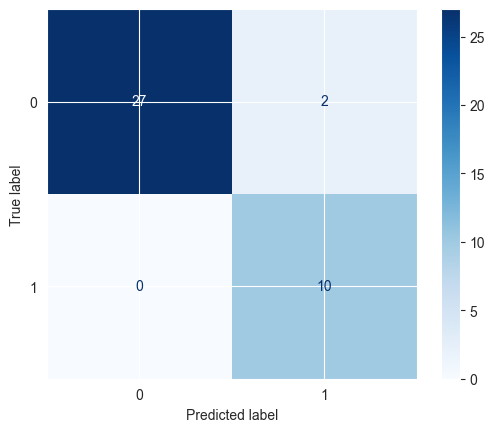

In [18]:
female = X_test[SEX] == "F"
ConfusionMatrixDisplay.from_predictions(y_test[female], y_test_pred[female], cmap="Blues")
plt.show()

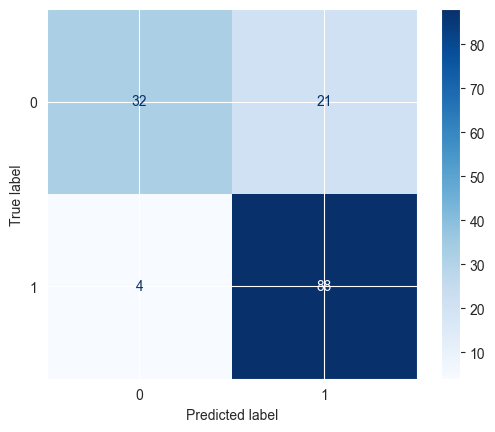

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test[~female], y_test_pred[~female], cmap="Blues")
plt.show()

Next, I want to consider the following questions:
- Comparison of models and their predictions. Do they have the same FN?
- Which model is currently the best?

In [ ]:
cv_results = optuna_cv_results_to_df(study)

with mlflow.start_run(run_name=MODEL_NAME) as run:
    best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
    mlflow.log_dict(best_cv_result, artifact_file="best_cv_result.json")
    for i in range(CV_SPLITS):
        mlflow.log_metric(f"cv_split_{i}_score", best_cv_result[f"split_test_{i}"])

    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", rem_cols.to_list())
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)
    mlflow.log_param("optuna_scoring", "prec_by_fixed_recall")
    mlflow.log_dict(cv_params, artifact_file="cv_params.json")
    mlflow.log_dict(cs_params, artifact_file="cs_params.json")

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")

    mlflow.set_tag("feature_selection", "shap")

## Version with raw features

In [37]:
obj_cols = df.select_dtypes(include=["object"]).columns
df[obj_cols] = df[obj_cols].astype("category")

In [38]:
y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

In [ ]:
fe_pipeline = FunctionTransformer(lambda x: x, validate=False)
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_xgboost_pipeline,
    param_space=xgboost_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
    cat_features=True,
    cv_scorer=cross_val_score_sw,
    cv_params=cv_params,
)

In [ ]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

In [ ]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

### Metrics

In [ ]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

In [ ]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

In [ ]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

In [ ]:
plot_pr_curve(y_val, y_val_proba)

Metrics are slightly worse on validation set and folds. Accordingly, it is better to use XGBoost with transformed features.